# Clasificación de *Helicobacter pylori* — MLP con Datos Aumentados por GAN

**Universidad Nacional de Colombia**

---

Extensión de la Entrega 1: mismo MLP *Shallow* entrenado con el dataset aumentado via GAN (`microbioma_aumentado_gan_CLR.csv`). La evaluación usa **Leave-One-Out CV sobre las 29 muestras originales** para medir el efecto real del augmentation en datos no vistos.

---

## 1. Library Imports

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


## 2. Data Loading

### Datasets
- **`microbioma_aumentado_gan_CLR.csv`**: muestras sintéticas generadas por la GAN. Columnas = géneros bacterianos + `Helicobacter_Pylori` (etiqueta 0/1). Sin `Sample_ID`.
- **Originales** (`-hp.csv` / `-nhp.csv`): 29 muestras reales con `Sample_ID` y metadatos. Solo se usan para evaluación LOO.

In [39]:
# --- Dataset aumentado por GAN ---
data_gan = pd.read_csv('/content/microbioma_aumentado_gan_CLR.csv')

# Separar features y etiqueta
LABEL_COL = 'Helicobacter_Pylori'
X_gan = data_gan.drop(columns=[LABEL_COL]).values
y_gan = data_gan[LABEL_COL].values

print(f"Dataset GAN: {X_gan.shape[0]} muestras, {X_gan.shape[1]} features")
print(f"Distribución clases GAN — 0: {(y_gan==0).sum()}, 1: {(y_gan==1).sum()}")

Dataset GAN: 2000 muestras, 60 features
Distribución clases GAN — 0: 1000, 1: 1000


In [40]:
print(binary_hp.columns.tolist())
print(binary_hp.head(3))

['Sample_ID', 'Hp_Status_binary', 'label_binary', 'Hp_CagA_Status', 'Score']
  Sample_ID Hp_Status_binary  label_binary Hp_CagA_Status          Score
0   P001Z12            H.p.-             0          H.p.-  not aplicable
1   P001Z13            H.p.-             0          H.p.-  not aplicable
2   P001Z14            H.p.-             0          H.p.-  not aplicable


In [41]:
# --- Datasets originales (para evaluación LOO) ---
data_hp   = pd.read_csv('/content/otu_genus_clr_prevfiltered-hp.csv')
binary_hp = pd.read_csv('/content/sample_metadata_binary-hp.csv')

data_nhp   = pd.read_csv('/content/otu_genus_clr_prevfiltered-nhp.csv')
binary_nhp = pd.read_csv('/content/sample_metadata_binary-nhp.csv')

def merge_labels(data_df, binary_df):
    merged = data_df.merge(binary_df[['Sample_ID', 'label_binary']], on='Sample_ID')
    X = merged.drop(columns=['Sample_ID', 'label_binary']).values
    y = merged['label_binary'].values
    return X, y

X_orig_hp,  y_orig_hp  = merge_labels(data_hp,  binary_hp)
X_orig_nhp, y_orig_nhp = merge_labels(data_nhp, binary_nhp)

print(f"Dataset original hp  (eval): {X_orig_hp.shape}")
print(f"Dataset original nhp (eval): {X_orig_nhp.shape}")

Dataset original hp  (eval): (29, 60)
Dataset original nhp (eval): (29, 59)


## 3. Preparación para NHP

El dataset GAN incluye la columna `Helicobacter` (el género completo). Para el escenario **sin Helicobacter** se elimina esa columna del set de entrenamiento GAN, igual que se hace en el original.

In [42]:
# Columnas del dataset GAN (sin la etiqueta)
feature_cols = data_gan.drop(columns=[LABEL_COL]).columns.tolist()
print(f"Features GAN ({len(feature_cols)}): {feature_cols[:5]} ... {feature_cols[-3:]}")

# Para NHP: eliminar columna 'Helicobacter' del set GAN
HELICOBACTER_COL = 'Helicobacter'

if HELICOBACTER_COL in feature_cols:
    X_gan_nhp = data_gan.drop(columns=[LABEL_COL, HELICOBACTER_COL]).values
    print(f"Dataset GAN-nhp: {X_gan_nhp.shape[1]} features (sin '{HELICOBACTER_COL}')")
else:
    print(f" Columna '{HELICOBACTER_COL}' no encontrada. Columnas disponibles:")
    print(feature_cols)
    X_gan_nhp = X_gan  # fallback

y_gan_nhp = y_gan  # etiquetas son las mismas

Features GAN (60): ['Actinobacillus', 'Actinomyces', 'Aggregatibacter', 'Alkalibacterium', 'Atopobium'] ... ['Unclassified', 'Veillonella', '[Prevotella]']
Dataset GAN-nhp: 59 features (sin 'Helicobacter')


## 4. MLP Architecture (igual que Entrega 1)

In [43]:
def build_mlp(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

## 5. LOO-CV con Entrenamiento GAN

**Protocolo por fold:**
1. Se aparta la muestra `i` del dataset original (test).
2. El modelo se entrena con **todo el dataset GAN** (sin tocar la muestra de test).
3. Se predice sobre la muestra `i` original.

El `StandardScaler` y `VarianceThreshold` se ajustan sobre el dataset GAN para evitar data leakage.

In [44]:
def run_loo_gan(X_train, y_train, X_eval, y_eval, dataset_name, epochs=100):
    """
    X_train / y_train : dataset GAN completo
    X_eval  / y_eval  : dataset original (29 muestras), usado solo para test LOO
    """
    # Preprocesamiento ajustado en los datos GAN
    selector = VarianceThreshold(threshold=0.01)
    X_train_sel = selector.fit_transform(X_train)
    X_eval_sel  = selector.transform(X_eval)

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train_sel)
    X_eval_sc  = scaler.transform(X_eval_sel)

    loo = LeaveOneOut()
    y_true, y_pred, y_prob = [], [], []

    tf.random.set_seed(42)
    np.random.seed(42)

    n = len(y_eval)
    for fold, (_, test_idx) in enumerate(loo.split(X_eval_sc)):
        X_test = X_eval_sc[test_idx]
        y_test = y_eval[test_idx]

        model = build_mlp(X_train_sc.shape[1])
        model.fit(
            X_train_sc, y_train,
            epochs=epochs,
            batch_size=16,
            verbose=0
        )

        prob = model.predict(X_test, verbose=0)[0][0]
        pred = int(prob >= 0.5)

        y_true.append(y_test[0])
        y_pred.append(pred)
        y_prob.append(prob)

        if (fold + 1) % 5 == 0 or fold == 0:
            print(f"  [{dataset_name}] Fold {fold+1}/{n} | real={y_test[0]}, pred={pred}, prob={prob:.3f}")

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)
    cm  = confusion_matrix(y_true, y_pred)

    print(f"\n{'='*55}")
    print(f"  [{dataset_name}] — MLP entrenado con datos GAN")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1-score : {f1:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"  Confusion matrix:\n{cm}")
    print(f"{'='*55}\n")

    return dict(accuracy=acc, f1=f1, auc=auc, cm=cm,
                y_true=y_true, y_pred=y_pred, y_prob=y_prob)

## 6. Ejecución — Dataset HP (con Helicobacter)

In [47]:
print(">>> Entrenando con GAN, evaluando en originales HP...")
results_hp = run_loo_gan(
    X_gan,      y_gan,
    X_orig_hp,  y_orig_hp,
    dataset_name='hp-GAN'
)

>>> Entrenando con GAN, evaluando en originales HP...
  [hp-GAN] Fold 1/29 | real=0, pred=1, prob=0.936
  [hp-GAN] Fold 5/29 | real=0, pred=1, prob=1.000
  [hp-GAN] Fold 10/29 | real=0, pred=0, prob=0.000
  [hp-GAN] Fold 15/29 | real=1, pred=1, prob=1.000
  [hp-GAN] Fold 20/29 | real=1, pred=1, prob=1.000
  [hp-GAN] Fold 25/29 | real=1, pred=1, prob=1.000

  [hp-GAN] — MLP entrenado con datos GAN
  Accuracy : 0.8276
  F1-score : 0.8889
  ROC-AUC  : 0.8889
  Confusion matrix:
[[ 4  5]
 [ 0 20]]



## 7. Ejecución — Dataset NHP (sin Helicobacter)

In [46]:
print(">>> Entrenando con GAN-nhp, evaluando en originales NHP")
results_nhp = run_loo_gan(
    X_gan_nhp,   y_gan_nhp,
    X_orig_nhp,  y_orig_nhp,
    dataset_name='nhp-GAN'
)

>>> Entrenando con GAN-nhp, evaluando en originales NHP
  [nhp-GAN] Fold 1/29 | real=0, pred=1, prob=1.000


  [nhp-GAN] Fold 5/29 | real=0, pred=1, prob=1.000


  [nhp-GAN] Fold 10/29 | real=0, pred=0, prob=0.000
  [nhp-GAN] Fold 15/29 | real=1, pred=0, prob=0.000
  [nhp-GAN] Fold 20/29 | real=1, pred=0, prob=0.000
  [nhp-GAN] Fold 25/29 | real=1, pred=0, prob=0.000

  [nhp-GAN] — MLP entrenado con datos GAN
  Accuracy : 0.2414
  F1-score : 0.2143
  ROC-AUC  : 0.2556
  Confusion matrix:
[[ 4  5]
 [17  3]]



## 8. Visualización — Matrices de Confusión

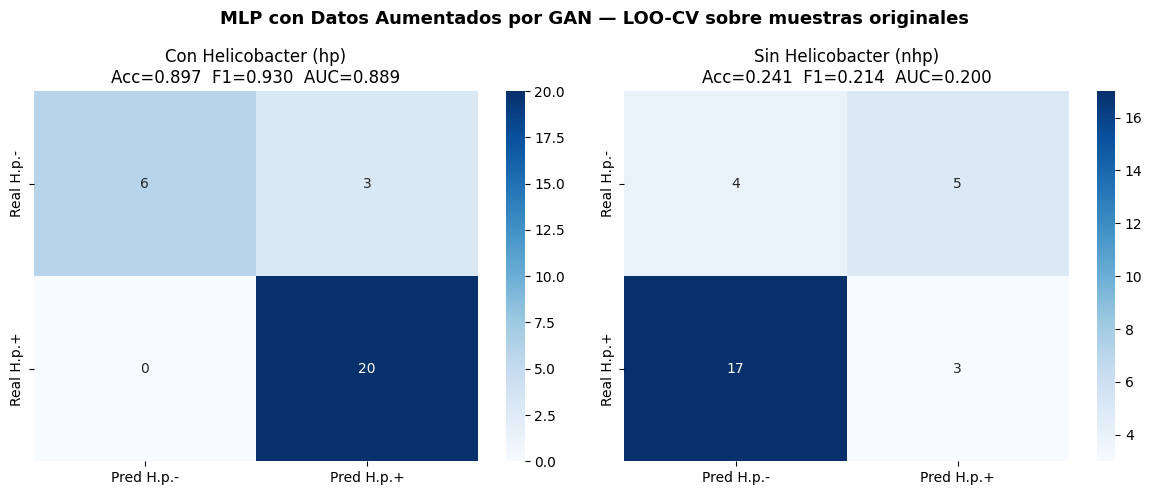

Figura guardada: mlp_gan_confusion_matrices.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('MLP con Datos Aumentados por GAN — LOO-CV sobre muestras originales',
             fontsize=13, fontweight='bold')

for ax, (res, title) in zip(axes, [
    (results_hp,  'Con Helicobacter (hp)'),
    (results_nhp, 'Sin Helicobacter (nhp)')
]):
    sns.heatmap(
        res['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Pred H.p.-', 'Pred H.p.+'],
        yticklabels=['Real H.p.-', 'Real H.p.+']
    )
    ax.set_title(
        f"{title}\nAcc={res['accuracy']:.3f}  F1={res['f1']:.3f}  AUC={res['auc']:.3f}"
    )

plt.tight_layout()
plt.savefig('mlp_gan_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: mlp_gan_confusion_matrices.png')

## 9. Comparación: Original vs. GAN Augmented

In [ ]:
# ────────────────────────────────
orig_hp_acc,  orig_hp_f1,  orig_hp_auc  = 0.0, 0.0, 0.0
orig_nhp_acc, orig_nhp_f1, orig_nhp_auc = 0.0, 0.0, 0.0
# ──────────────────────────────────────────────────────────────────────────

comparison = pd.DataFrame([
    {'Dataset': 'hp',  'Método': 'Original (Entrega 1)',
     'Accuracy': orig_hp_acc,  'F1': orig_hp_f1,  'AUC': orig_hp_auc},
    {'Dataset': 'hp',  'Método': 'GAN Augmented',
     'Accuracy': results_hp['accuracy'],  'F1': results_hp['f1'],  'AUC': results_hp['auc']},
    {'Dataset': 'nhp', 'Método': 'Original (Entrega 1)',
     'Accuracy': orig_nhp_acc, 'F1': orig_nhp_f1, 'AUC': orig_nhp_auc},
    {'Dataset': 'nhp', 'Método': 'GAN Augmented',
     'Accuracy': results_nhp['accuracy'], 'F1': results_nhp['f1'], 'AUC': results_nhp['auc']},
])

display(comparison.style.format({'Accuracy': '{:.4f}', 'F1': '{:.4f}', 'AUC': '{:.4f}'}))
comparison.to_csv('mlp_comparison_original_vs_gan.csv', index=False)
print('Tabla guardada: mlp_comparison_original_vs_gan.csv')

,Dataset,Método,Accuracy,F1,AUC
0,hp,Original (Entrega 1),0.0000,0.0000,0.0000
1,hp,GAN Augmented,0.8966,0.9302,0.8889
2,nhp,Original (Entrega 1),0.0000,0.0000,0.0000
3,nhp,GAN Augmented,0.2414,0.2143,0.2000


Tabla guardada: mlp_comparison_original_vs_gan.csv
